I have tried optimising with a and theta together. I am first picking an initial point with a and theta s.t. argmin of Frobenius norm to estimated cov of obs_norm. 

Then I run th eoptimisation with those as initial points. I use 103 sims with a fixed seed. I then do Cholesky decomposition to make them dependent. I have a penalty if estimated_cov.median() < 0.01 to discourage sparse covariances. lr=0.2 and I use torch.nn.utils.clip_grad_norm_([theta_, a_], max_norm=1e-2). 

Running this for 7500 epochs, gives theta=73.461265 and a.exp()=0.038154. The resulting samples prioritise altitude way too much, creating bubbe patterns.

To remedy this, I fix a and infer theta only, as done here.

In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.gaussian_process.kernels import Matern
import torch
import torch.nn as nn
from torch import tensor as tt

import sys as sys
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
import netCDF4 as nc


In [2]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

def revert_to_indep_gauss(dependent_samples, chol_cov):
    return dependent_samples @ torch.linalg.inv(chol_cov).T

norm = torch.distributions.Normal(0.0, 1.0)


# Importing data


In [3]:
#################################################################### Loading GNM ####################################################################
sys.path.append('../')

import pickle


GNM_output = pickle.load( open("trainset_output_1979_1993-03.pkl","rb") )
#################################################################### Problematic locations? ###############################################################

location_keys = list(GNM_output.keys())                 # '([0, 16], [44, 60])', ...
output_keys = list(GNM_output[location_keys[0]].keys()) # 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'date', 5'pred_p', 6'mask', 7'idx_loc_in_region'

# May have to remove a location that doesn't have the correct number of days:
#location_keys.remove(location_keys[344]) #to remove for gamma_20_20 from 1999-2019 
location_keys.remove(location_keys[336]) #to remove for gamma_20_20 from 1979-1999
#################################################################### Utility functions ####################################################################
def give_lat_lon(location_key):
    return [ int(re.findall(r'\d+',string)[0]) for string in location_key.split(',')]

def is_loc_land(location,row,column):
    return GNM_output[location]['mask'][0][row][column]

#location_keys.remove('lat_50.95_49.35_lon_-4.55_-2.95') # 'lat_50.95_49.35_lon_-4.55_-2.95' has no data after week indexed 255, so I did not consider it.
day_dates = [pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date']]
output_keys.remove('idx_loc_in_region') # not usefull
output_keys.remove('date') # no more usefull

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

GNM_landonly = [] 
land_counter = -1
for location in tqdm(location_keys):
    for col in range(4):
        for row in range(4):
            if not is_loc_land(location,row,col):#check if land
               continue  
            land_counter+=1
            GNM_landonly.append([[],[],[],[],[]]) # parameters except location
            temp_lat_lon = give_lat_lon(location)
            GNM_landonly[land_counter].append([temp_lat_lon[1]-8+row,(temp_lat_lon[2])+6+col]) #location
            for param_idx,param in enumerate(output_keys[:-1]):
                for day in range(len(GNM_output[location_keys[0]]['pred_mu'])):
                    qqq = [location,param,day,row,col]
                    GNM_landonly[land_counter][param_idx].append(GNM_output[location][param][day][row,col])

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))

#################################################################### Elevation data ####################################################################
fn = 'topo_0.1_degree.nc'
ds = nc.Dataset(fn)
h = ds['Band1'][:]
h = np.flip(np.matrix(h),axis=0)
topo_dist = euclidean_distances(np.array([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1))

# load obs_norm_all and censor_levels_di
obs_norm_all = np.load('obs_norm_all_trainCdf_1979_1999.npy')
censor_levels_di = np.load('censor_levels_di_trainCdf_1979_1999.npy')
censor_levels_u = scs.norm.cdf(censor_levels_di)

100%|██████████| 344/344 [00:52<00:00,  6.61it/s]


# Finding initial parameters

In [4]:
emp_cov_z = np.cov(obs_norm_all.T)
emp_cov_z = tt(emp_cov_z, dtype=torch.float64)

obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
censor_levels_di = tt(censor_levels_di, dtype=torch.float64)

20it [00:59,  2.98s/it]
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1708468717.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))


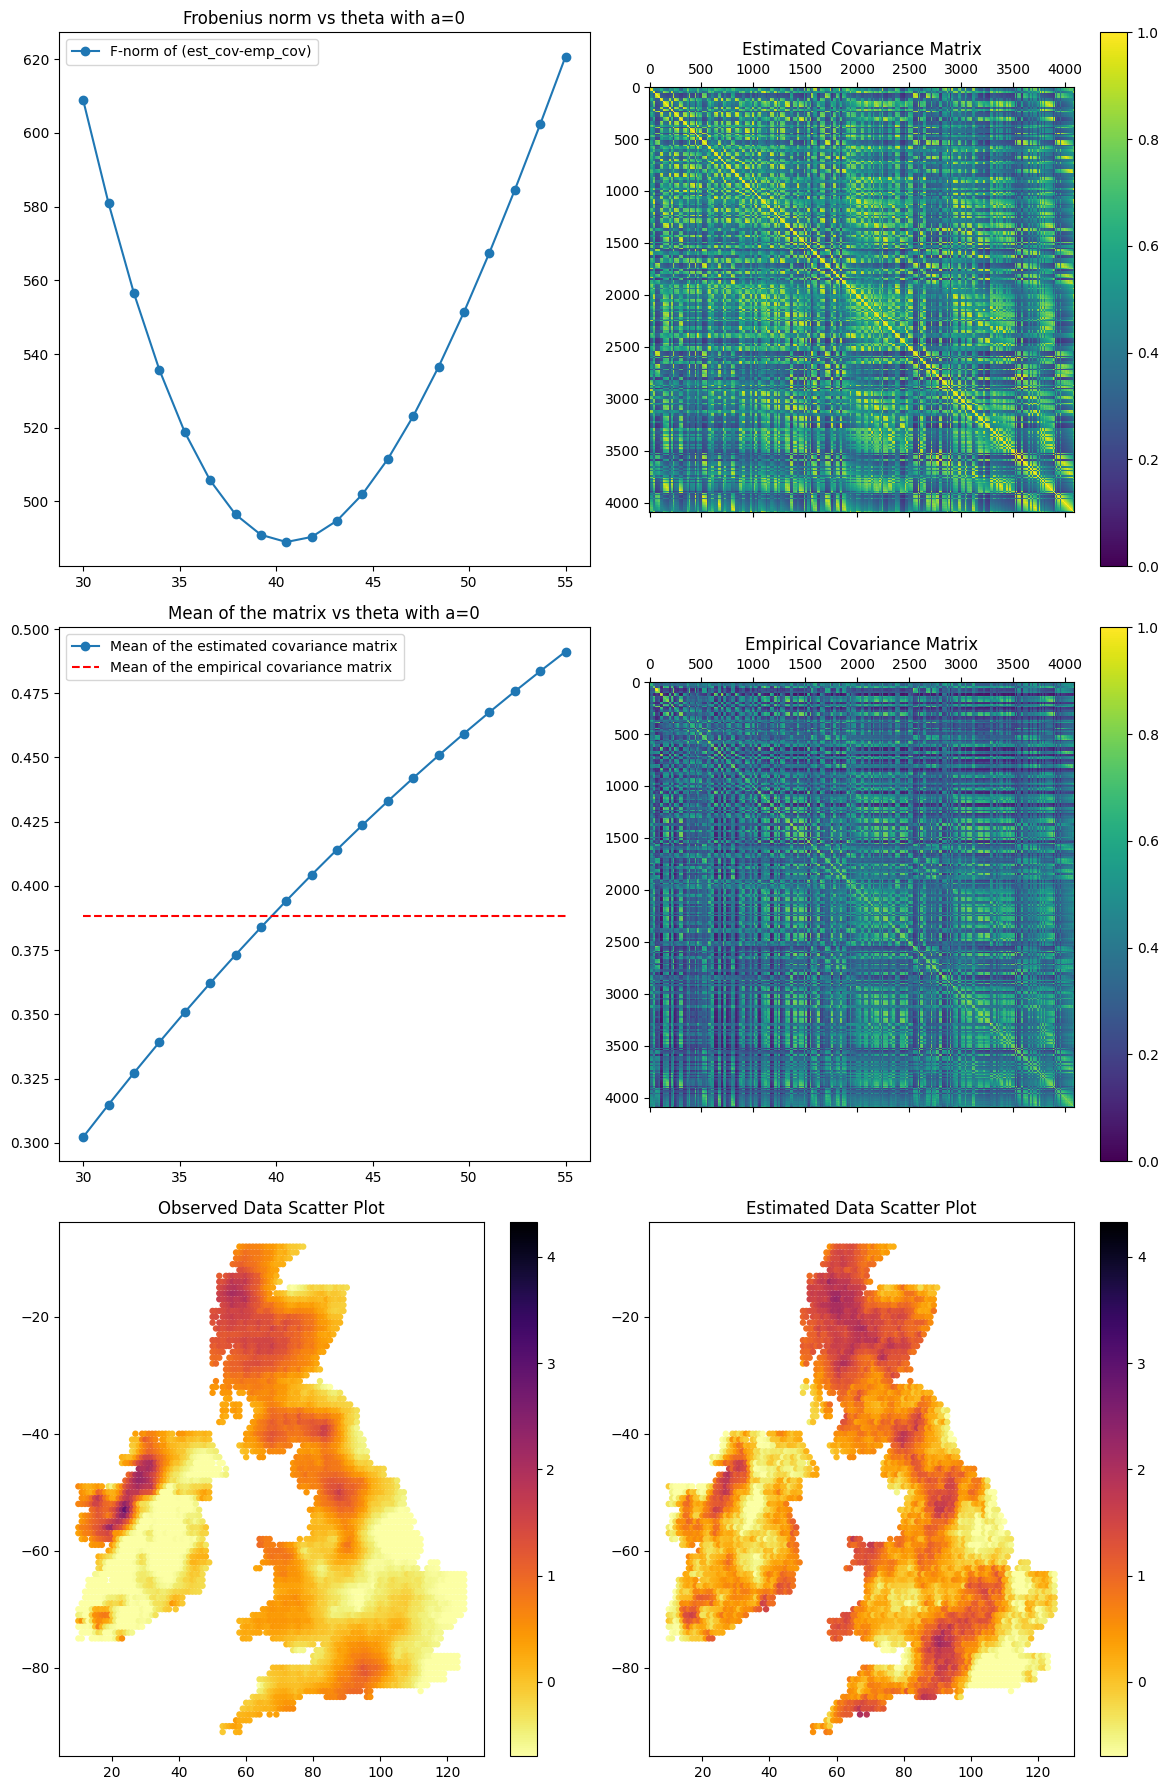

In [5]:
# compute Frobenius norm for different theta and a = 0
theta_values_a0 = torch.linspace(30, 55, 20)

frobenius_norms = np.zeros((len(theta_values_a0)))
mat_means = np.zeros((len(theta_values_a0)))

fixed_noise = norm.sample((obs_norm_all.shape[0], obs_norm_all.shape[1])).to(dtype=torch.float64)

estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for i,theta in tqdm(enumerate(theta_values_a0)):

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta)
    sims = sample_Gauss_fixed_noise(fixed_noise, torch.linalg.cholesky(estimated_cov))
    est_cov_est_z = torch.cov(sims.T)
    frobenius_norms[i] = torch.norm(est_cov_est_z - emp_cov_z, p='fro').item()
    mat_means[i] = torch.mean(est_cov_est_z).item()

# min theta
theta_a0 = theta_values_a0[frobenius_norms.argmin()]

# Get samples from the estimated covariance matrix
fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))
sim_z_est_a0 = sample_Gauss_fixed_noise(fixed_noise_reverted, torch.linalg.cholesky(torch_Matern_05(estimated_dist_matrix, tt(34.821178436279))))
sim_z_est_censored_a0 = torch.maximum(sim_z_est_a0, censor_levels_di)

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Frobenius norm vs theta
axs[0, 0].plot(theta_values_a0, frobenius_norms, 'o-', label='F-norm of (est_cov-emp_cov)')
axs[0, 0].set_title('Frobenius norm vs theta with a=0')
axs[0, 0].legend()

# Plot mean of the covariance matrix vs theta
axs[1, 0].plot(theta_values_a0, mat_means, 'o-', label='Mean of the estimated covariance matrix')
axs[1, 0].hlines(torch.mean(emp_cov_z).item(), theta_values_a0[0], theta_values_a0[-1], colors='r', linestyles='dashed', label='Mean of the empirical covariance matrix')
axs[1, 0].set_title('Mean of the matrix vs theta with a=0')
axs[1, 0].legend()

# Plot estimated covariance matrix
im_est = axs[0, 1].matshow(estimated_cov.detach().numpy(), vmin=0, vmax=1)
axs[0, 1].set_title('Estimated Covariance Matrix')
fig.colorbar(im_est, ax=axs[0, 1])

# Plot empirical covariance matrix
im_emp = axs[1, 1].matshow(emp_cov_z.detach().numpy(), vmin=0, vmax=1)
axs[1, 1].set_title('Empirical Covariance Matrix')
fig.colorbar(im_emp, ax=axs[1, 1])

# Plot the first sample of observed data on the map
day = 0  # Example day
min_val = min([obs_norm_all[day].min(), sim_z_est_censored_a0[day].min()])
max_val = max([obs_norm_all[day].max(), sim_z_est_censored_a0[day].max()])

sc_obs = axs[2, 0].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=obs_norm_all[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)
axs[2, 0].set_title('Observed Data Scatter Plot')
fig.colorbar(sc_obs, ax=axs[2, 0])

# Plot the first sample of estimated data on the map
sc_est = axs[2, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=sim_z_est_censored_a0[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)

axs[2, 1].set_title('Estimated Data Scatter Plot')
fig.colorbar(sc_est, ax=axs[2, 1])

plt.tight_layout()
plt.show()

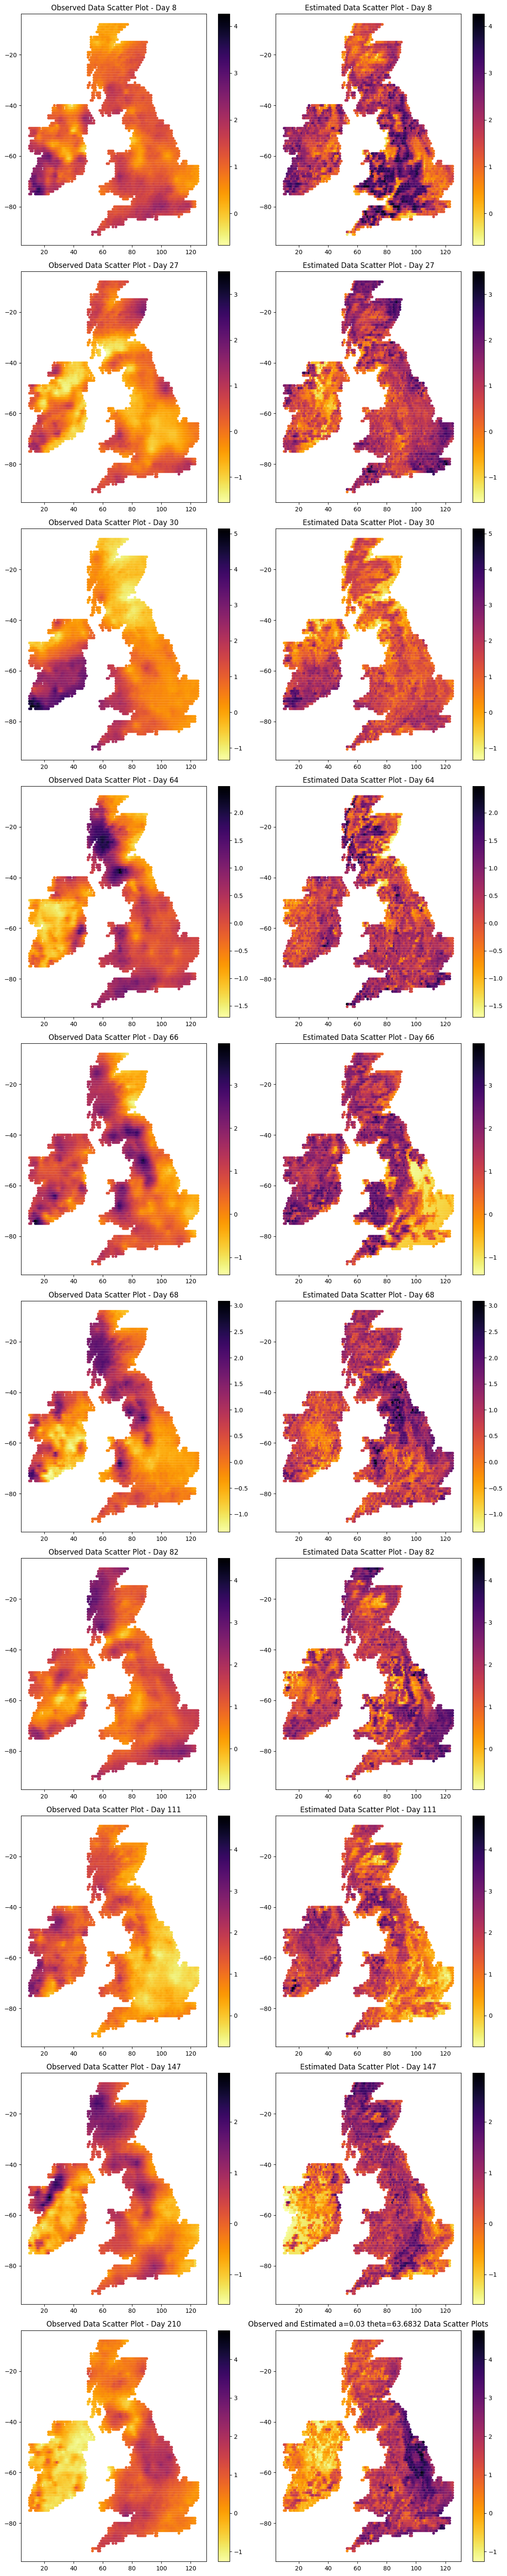

In [32]:
# Create a 10 by 2 subplot
indices = torch.argwhere((obs_norm_all > (censor_levels_di + 0.1)).to(dtype=torch.float64).mean(1) > 0.99)

fig, axs = plt.subplots(10, 2, figsize=(12, 60))

for d in range(10):
    day = indices[d].item()
    min_val = min([obs_norm_all[day].min(), sim_z_est_censored_a03[day].min()])
    max_val = max([obs_norm_all[day].max(), sim_z_est_censored_a03[day].max()])

    # Plot the observed data for the day
    sc_obs = axs[d, 0].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                                 [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                                 c=obs_norm_all[day].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)
    axs[d, 0].set_title(f'Observed Data Scatter Plot - Day {day}')
    fig.colorbar(sc_obs, ax=axs[d, 0])

    # Plot the simulated data for the day
    sc_est = axs[d, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                                 [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                                 c=sim_z_est_censored_a03[day].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)
    axs[d, 1].set_title(f'Estimated Data Scatter Plot - Day {day}')
    fig.colorbar(sc_est, ax=axs[d, 1])

plt.title('Observed and Estimated a=0.03 theta=63.6832 Data Scatter Plots')
plt.tight_layout()
plt.show()

20it [00:48,  2.44s/it]
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1220693772.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))


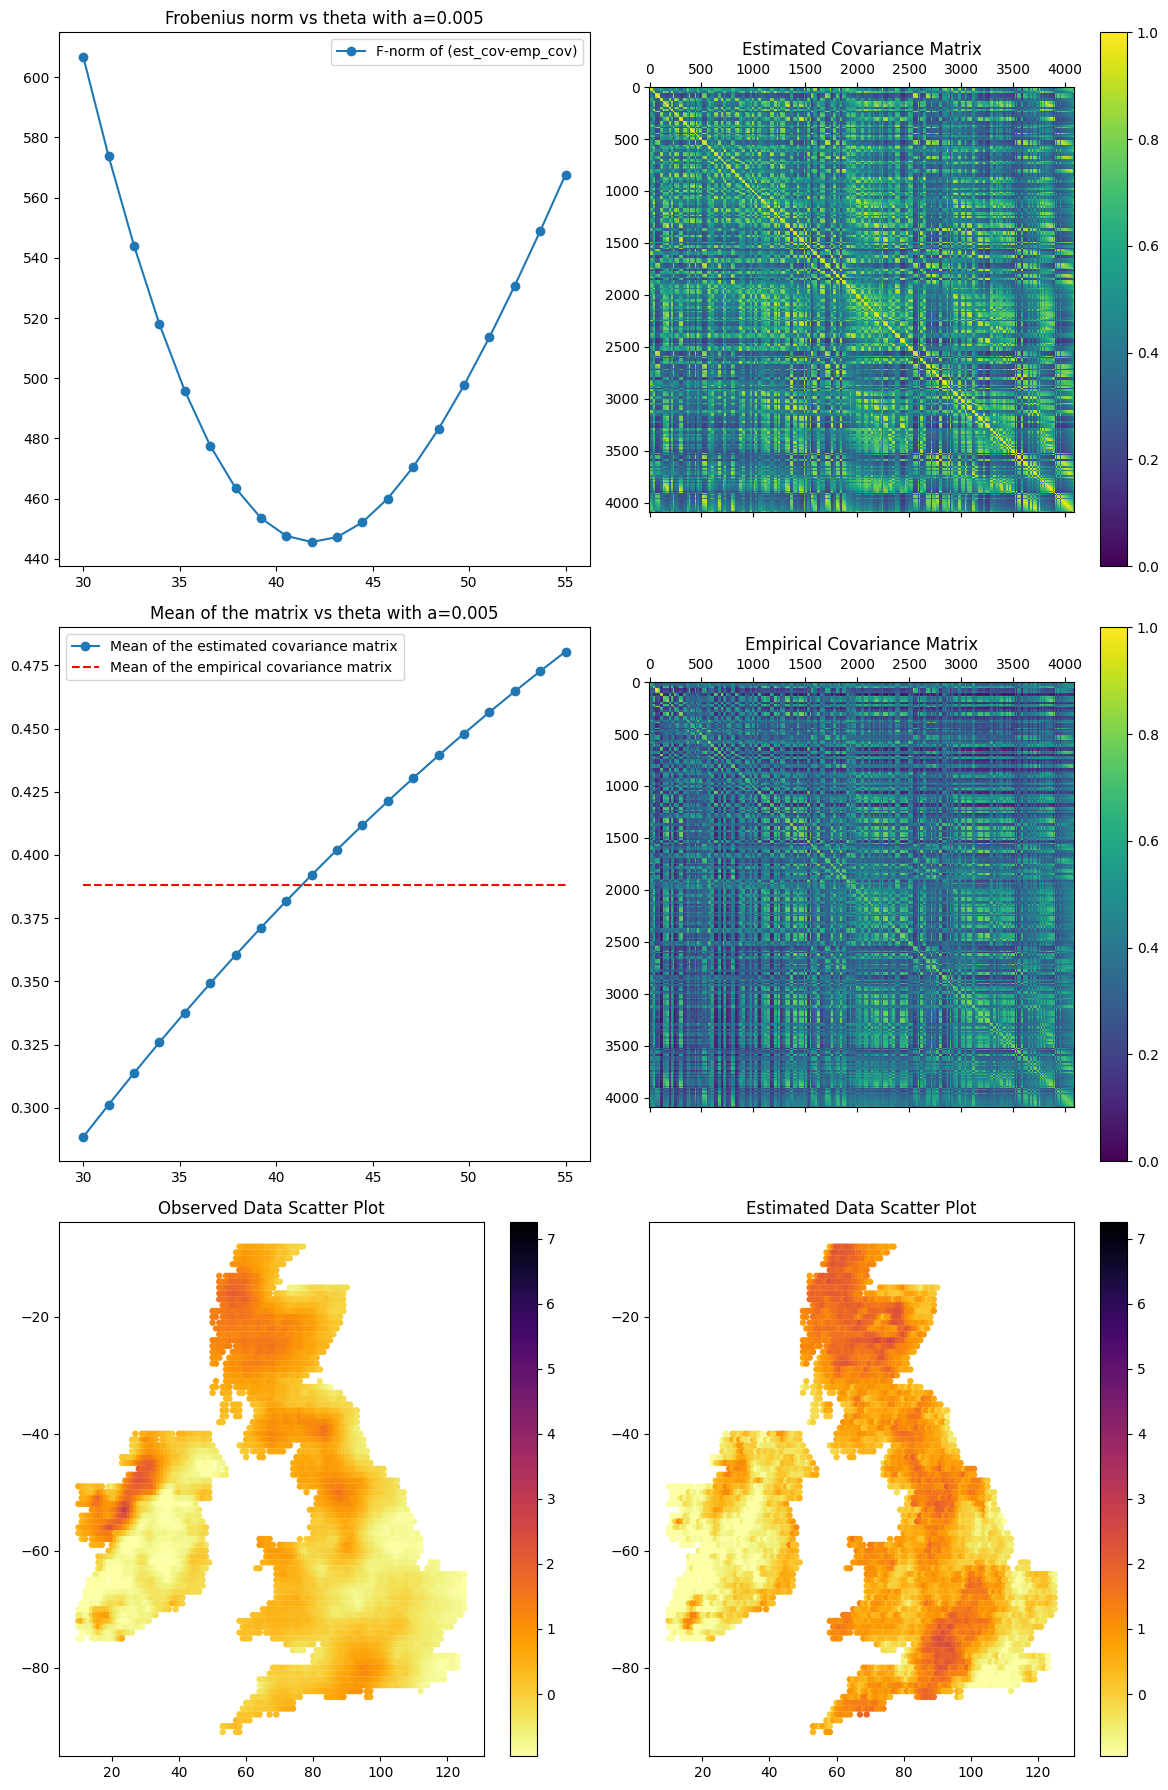

In [14]:
# compute Frobenius norm for different theta and a = 0.01
theta_values_a01 = torch.linspace(30, 55, 20)

frobenius_norms = np.zeros((len(theta_values_a01)))
mat_means = np.zeros((len(theta_values_a01)))

fixed_noise = norm.sample((obs_norm_all.shape[0], obs_norm_all.shape[1])).to(dtype=torch.float64)

estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.005*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for i,theta in tqdm(enumerate(theta_values_a01)):

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta)
    sims = sample_Gauss_fixed_noise(fixed_noise, torch.linalg.cholesky(estimated_cov))
    est_cov_est_z = torch.cov(sims.T)
    frobenius_norms[i] = torch.norm(est_cov_est_z - emp_cov_z, p='fro').item()
    mat_means[i] = torch.mean(est_cov_est_z).item()

# min theta
theta_a005 = tt(36.4930)#theta_values_a01[frobenius_norms.argmin()]

# Get samples from the estimated covariance matrix
fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))
sim_z_est_a01 = sample_Gauss_fixed_noise(fixed_noise_reverted, torch.linalg.cholesky(torch_Matern_05(estimated_dist_matrix, theta_a005)))
sim_z_est_censored_a01 = torch.maximum(sim_z_est_a01, censor_levels_di)

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Frobenius norm vs theta
axs[0, 0].plot(theta_values_a01, frobenius_norms, 'o-', label='F-norm of (est_cov-emp_cov)')
axs[0, 0].set_title('Frobenius norm vs theta with a=0.005')
axs[0, 0].legend()

# Plot mean of the covariance matrix vs theta
axs[1, 0].plot(theta_values_a01, mat_means, 'o-', label='Mean of the estimated covariance matrix')
axs[1, 0].hlines(torch.mean(emp_cov_z).item(), theta_values_a01[0], theta_values_a01[-1], colors='r', linestyles='dashed', label='Mean of the empirical covariance matrix')
axs[1, 0].set_title('Mean of the matrix vs theta with a=0.005')
axs[1, 0].legend()

# Plot estimated covariance matrix
im_est = axs[0, 1].matshow(estimated_cov.detach().numpy(), vmin=0, vmax=1)
axs[0, 1].set_title('Estimated Covariance Matrix')
fig.colorbar(im_est, ax=axs[0, 1])

# Plot empirical covariance matrix
im_emp = axs[1, 1].matshow(emp_cov_z.detach().numpy(), vmin=0, vmax=1)
axs[1, 1].set_title('Empirical Covariance Matrix')
fig.colorbar(im_emp, ax=axs[1, 1])

# Plot the first sample of observed data on the map
day = 0  # Example day
min_val = min([obs_norm_all[day].min(), sim_z_est_censored_a01[day].min()])
max_val = max([obs_norm_all[day].max(), sim_z_est_censored_a01[day].max()])

sc_obs = axs[2, 0].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=obs_norm_all[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)
axs[2, 0].set_title('Observed Data Scatter Plot')
fig.colorbar(sc_obs, ax=axs[2, 0])

# Plot the first sample of estimated data on the map
sc_est = axs[2, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=sim_z_est_censored_a01[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)

axs[2, 1].set_title('Estimated Data Scatter Plot')
fig.colorbar(sc_est, ax=axs[2, 1])

plt.tight_layout()
plt.show()

20it [00:44,  2.24s/it]
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1308029341.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))


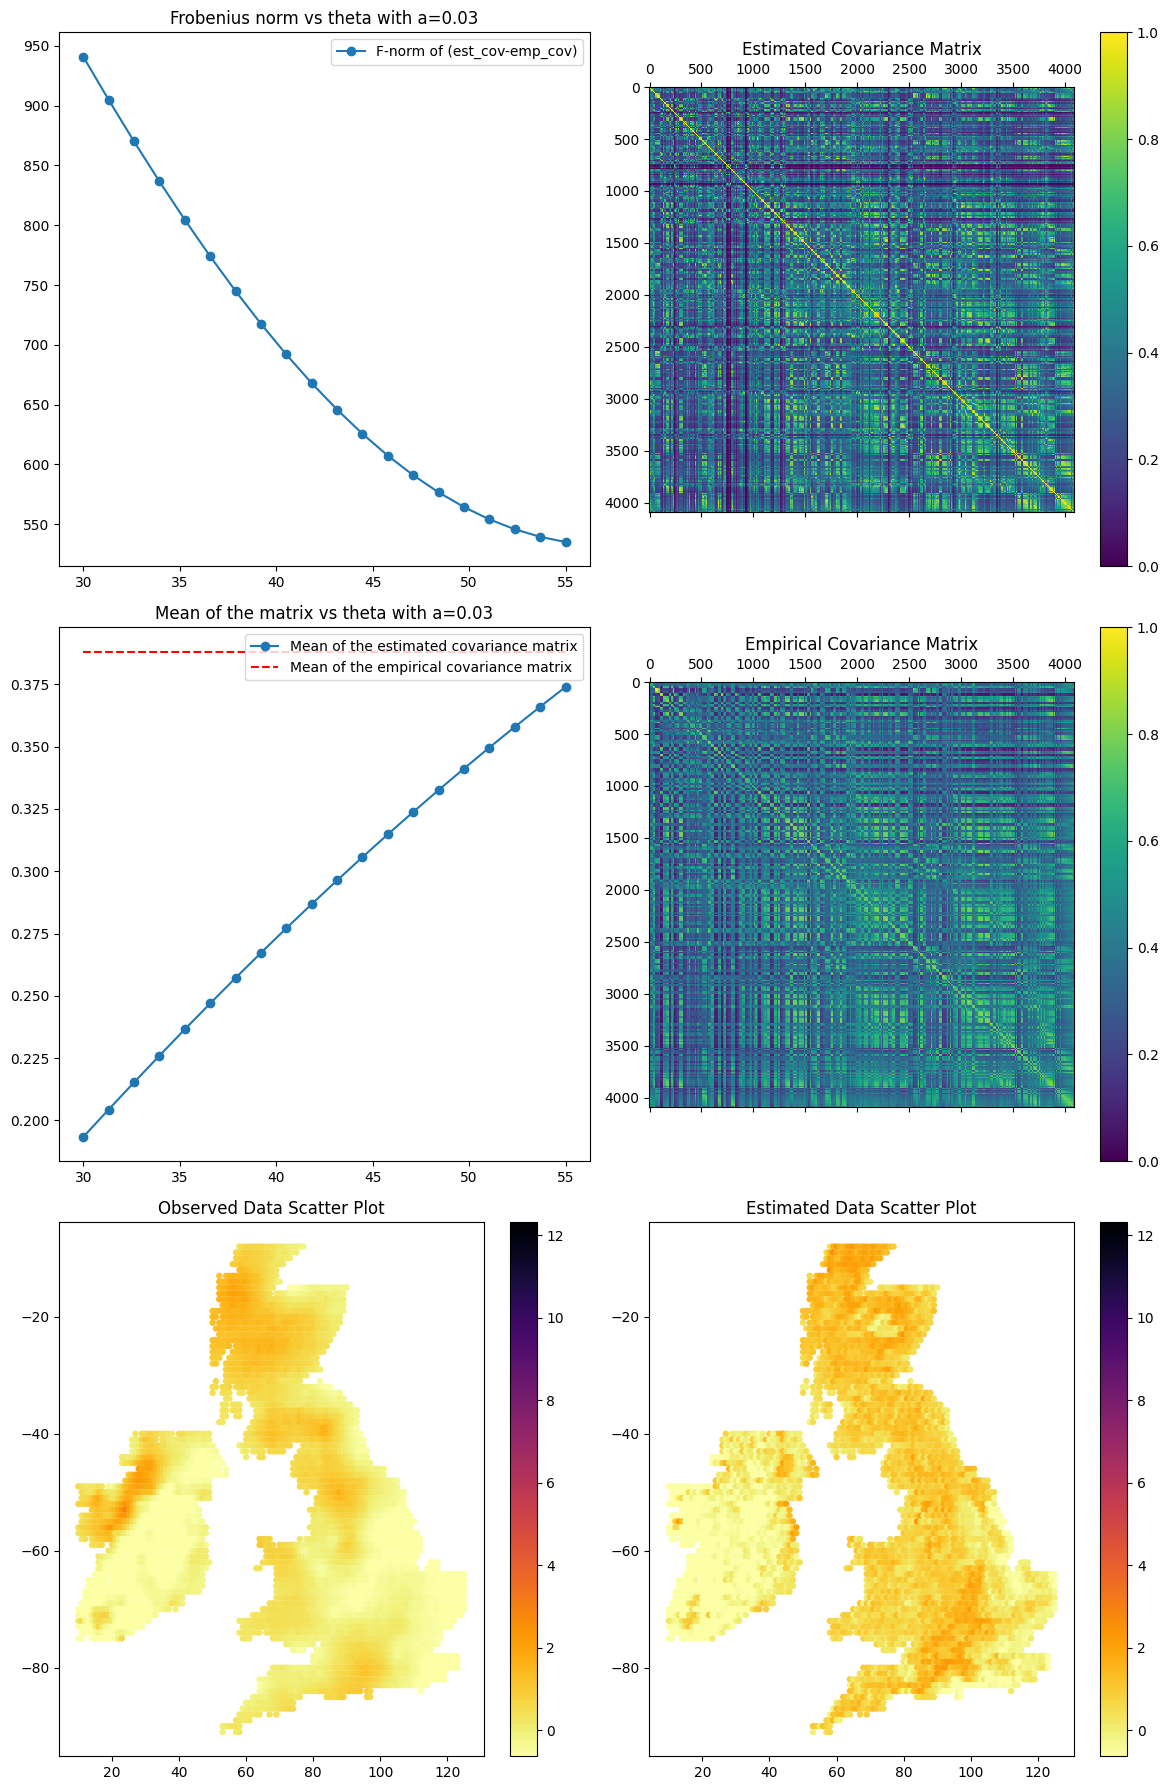

In [15]:
# compute Frobenius norm for different theta and a = 0.03
theta_values_a03 = torch.linspace(30, 55, 20)

frobenius_norms = np.zeros((len(theta_values_a03)))
mat_means = np.zeros((len(theta_values_a03)))

fixed_noise = norm.sample((obs_norm_all.shape[0], obs_norm_all.shape[1])).to(dtype=torch.float64)

estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.03*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for i,theta in tqdm(enumerate(theta_values_a03)):

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta)
    sims = sample_Gauss_fixed_noise(fixed_noise, torch.linalg.cholesky(estimated_cov))
    est_cov_est_z = torch.cov(sims.T)
    frobenius_norms[i] = torch.norm(est_cov_est_z - emp_cov_z, p='fro').item()
    mat_means[i] = torch.mean(est_cov_est_z).item()

# min theta
theta_a03 = tt(63.6832)#theta_values_a03[frobenius_norms.argmin()]

# Get samples from the estimated covariance matrix
fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all), torch.linalg.cholesky(emp_cov_z))
sim_z_est_a03 = sample_Gauss_fixed_noise(fixed_noise_reverted, torch.linalg.cholesky(torch_Matern_05(estimated_dist_matrix, theta_a03)))
sim_z_est_censored_a03 = torch.maximum(sim_z_est_a03, censor_levels_di)

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Frobenius norm vs theta
axs[0, 0].plot(theta_values_a03, frobenius_norms, 'o-', label='F-norm of (est_cov-emp_cov)')
axs[0, 0].set_title('Frobenius norm vs theta with a=0.03')
axs[0, 0].legend()

# Plot mean of the covariance matrix vs theta
axs[1, 0].plot(theta_values_a03, mat_means, 'o-', label='Mean of the estimated covariance matrix')
axs[1, 0].hlines(torch.mean(emp_cov_z).item(), theta_values_a03[0], theta_values_a03[-1], colors='r', linestyles='dashed', label='Mean of the empirical covariance matrix')
axs[1, 0].set_title('Mean of the matrix vs theta with a=0.03')
axs[1, 0].legend()

# Plot estimated covariance matrix
im_est = axs[0, 1].matshow(estimated_cov.detach().numpy(), vmin=0, vmax=1)
axs[0, 1].set_title('Estimated Covariance Matrix')
fig.colorbar(im_est, ax=axs[0, 1])

# Plot empirical covariance matrix
im_emp = axs[1, 1].matshow(emp_cov_z.detach().numpy(), vmin=0, vmax=1)
axs[1, 1].set_title('Empirical Covariance Matrix')
fig.colorbar(im_emp, ax=axs[1, 1])

# Plot the first sample of observed data on the map
day = 0  # Example day
min_val = min([obs_norm_all[day].min(), sim_z_est_censored_a03[day].min()])
max_val = max([obs_norm_all[day].max(), sim_z_est_censored_a03[day].max()])

sc_obs = axs[2, 0].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=obs_norm_all[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)
axs[2, 0].set_title('Observed Data Scatter Plot')
fig.colorbar(sc_obs, ax=axs[2, 0])

# Plot the first sample of estimated data on the map
sc_est = axs[2, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                            c=sim_z_est_censored_a03[147].detach().numpy(), cmap='inferno_r', vmin=min_val, vmax=max_val, s=13)

axs[2, 1].set_title('Estimated Data Scatter Plot')
fig.colorbar(sc_est, ax=axs[2, 1])

plt.tight_layout()
plt.show()

# Optimising full data

In [ ]:
#
# optimisation a = 0
#

torch.manual_seed(3)

censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
fixed_noise = norm.sample((103,len(GNM_landonly))).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta_a0_optim = tt(theta_a0,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta_a0_optim], lr=0.2)

history1 = []

# construct current guess of the Distance Matrix
estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for epoch in range(500):
    optimizer.zero_grad()    

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta_a0_optim)

    # sample
    chol_cov_est = torch.linalg.cholesky(estimated_cov)
    sims_z_est = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est) # on the Gaussian Z-space
    SR = 0
    for i in range(50): # loop over all days in subsets
        day_subset = range(i*103,(i+1)*103)
        sim_z_est_censored = torch.maximum(sims_z_est, censor_levels_di[day_subset,:] )
        #sims_u_est = norm.cdf(sims_z_est) # convert to U-space
        SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored) 
    # add last batch of days
    day_subset = [day for day in range(5149+1,len(GNM_landonly[0][0]))]
    sim_z_est_censored = torch.maximum(sims_z_est[:len(day_subset)], censor_levels_di[day_subset,:] )
    SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored)
    
    # penalize if estimated_cov is too small 
    if estimated_cov.median() < 0.01:
        SR = SR * (1/estimated_cov.mean())
        print(epoch,'penalizing', 1e-2* 1/estimated_cov.mean().item())
    SR.backward()

    # Clip gradients
    torch.nn.utils.clip_grad_norm_([theta_a0_optim], max_norm=1e-2)

    if epoch % 1 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {SR.item()}, Theta Gradient = {theta_a0_optim.grad.item()}, Theta = {theta_a0_optim.item()}')
        history1.append([theta_a0_optim.item(), SR.item()])
    optimizer.step()

print(theta_a0_optim)



np.save('theta_a0_optim.npy', history1)

C:\Users\u1819911\AppData\Local\Temp\ipykernel_14904\3102067215.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_14904\3102067215.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_14904\3102067215.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_a0_optim = tt(theta_a0,requires_grad=True)


Epoch 0: Loss = 433.87490781256065, Theta Gradient = 0.006158445030450821, Theta = 40.52631378173828
Epoch 1: Loss = 433.8736962413722, Theta Gradient = 0.00599038926884532, Theta = 40.32631301879883
Epoch 2: Loss = 433.8725388765456, Theta Gradient = 0.005781260784715414, Theta = 40.1264762878418
Epoch 3: Loss = 433.8713881356454, Theta Gradient = 0.005626946687698364, Theta = 39.92698287963867
Epoch 4: Loss = 433.8702829320893, Theta Gradient = 0.0054560378193855286, Theta = 39.72789764404297
Epoch 5: Loss = 433.8692174444915, Theta Gradient = 0.005279311910271645, Theta = 39.52934646606445
Epoch 6: Loss = 433.86820515732416, Theta Gradient = 0.005103256553411484, Theta = 39.331478118896484
Epoch 7: Loss = 433.86721792573337, Theta Gradient = 0.004778985865414143, Theta = 39.134437561035156
Epoch 8: Loss = 433.8663012536674, Theta Gradient = 0.0046744816936552525, Theta = 38.938743591308594
Epoch 9: Loss = 433.8653930651461, Theta Gradient = 0.004506360739469528, Theta = 38.744293212

IndexError: index 2 is out of bounds for axis 1 with size 2

C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\298170908.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\298170908.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\298170908.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_a005_optim = tt(theta_a005,requires_grad=True)


Epoch 0: Loss = 433.7309076788819, Theta Gradient = 0.004360542166978121, Theta = 40.52631378173828
Epoch 1: Loss = 433.7300898716618, Theta Gradient = 0.004105018451809883, Theta = 40.32631301879883
Epoch 2: Loss = 433.7293016080789, Theta Gradient = 0.003869518404826522, Theta = 40.1267204284668
Epoch 3: Loss = 433.72853685052445, Theta Gradient = 0.0037397192791104317, Theta = 39.92778778076172
Epoch 4: Loss = 433.7277972707309, Theta Gradient = 0.0035699319560080767, Theta = 39.7294807434082
Epoch 5: Loss = 433.7271040462982, Theta Gradient = 0.00338758178986609, Theta = 39.53201675415039
Epoch 6: Loss = 433.72647564312, Theta Gradient = 0.003190473187714815, Theta = 39.33566665649414
Epoch 7: Loss = 433.72586351935473, Theta Gradient = 0.002801185939460993, Theta = 39.14076614379883
Epoch 8: Loss = 433.7253259835713, Theta Gradient = 0.0027731775771826506, Theta = 38.94849395751953
Epoch 9: Loss = 433.7248130589552, Theta Gradient = 0.00258632842451334, Theta = 38.7582893371582
Ep

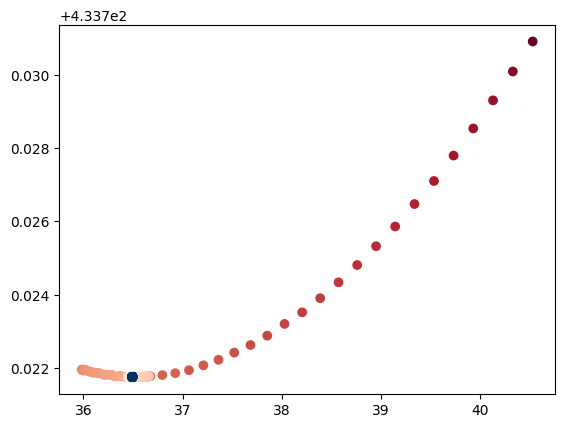

In [12]:
#
# optimisation a = 0.005
#

torch.manual_seed(3)

censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
fixed_noise = norm.sample((103,len(GNM_landonly))).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta_a005_optim = tt(theta_a005,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta_a005_optim], lr=0.2)

history2 = []

# construct current guess of the Distance Matrix
estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.005*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for epoch in range(500):
    optimizer.zero_grad()    

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta_a005_optim)

    # sample
    chol_cov_est = torch.linalg.cholesky(estimated_cov)
    sims_z_est = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est) # on the Gaussian Z-space
    SR = 0
    for i in range(50): # loop over all days in subsets
        day_subset = range(i*103,(i+1)*103)
        sim_z_est_censored = torch.maximum(sims_z_est, censor_levels_di[day_subset,:] )
        #sims_u_est = norm.cdf(sims_z_est) # convert to U-space
        SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored) 
    # add last batch of days
    day_subset = [day for day in range(5149+1,len(GNM_landonly[0][0]))]
    sim_z_est_censored = torch.maximum(sims_z_est[:len(day_subset)], censor_levels_di[day_subset,:] )
    SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored)
    
    # penalize if estimated_cov is too small 
    if estimated_cov.median() < 0.01:
        SR = SR * (1/estimated_cov.mean())
        print(epoch,'penalizing', 1e-2* 1/estimated_cov.mean().item())
    SR.backward()

    # Clip gradients
    torch.nn.utils.clip_grad_norm_([theta_a005_optim], max_norm=1e-2)

    if epoch % 1 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {SR.item()}, Theta Gradient = {theta_a005_optim.grad.item()}, Theta = {theta_a005_optim.item()}')
        history2.append([theta_a005_optim.item(), SR.item()])
    optimizer.step()

print(theta_a005_optim)

# Extract theta, a, and SR values from history2
history2 = np.array(history2)

plt.scatter(history2[:, 0], history2[:, 1], c = np.sqrt(np.arange(len(history2))), cmap = 'RdBu')

np.save('theta_a005_optim.npy', history2)

C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1170793988.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1170793988.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5168\1170793988.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_a03_optim = tt(theta_a03,requires_grad=True)


Epoch 0: Loss = 433.00098836634953, Theta Gradient = -0.009999411180615425, Theta = 45.78947448730469
Epoch 1: Loss = 432.99761306119785, Theta Gradient = -0.009999404661357403, Theta = 45.98947525024414
Epoch 2: Loss = 432.99430438888453, Theta Gradient = -0.009999389760196209, Theta = 46.189476013183594
Epoch 3: Loss = 432.9910648154763, Theta Gradient = -0.009999379515647888, Theta = 46.38947677612305
Epoch 4: Loss = 432.9878646312612, Theta Gradient = -0.009999368339776993, Theta = 46.5894775390625
Epoch 5: Loss = 432.98471489344763, Theta Gradient = -0.009999357163906097, Theta = 46.78947830200195
Epoch 6: Loss = 432.9816254655732, Theta Gradient = -0.009999345988035202, Theta = 46.989479064941406
Epoch 7: Loss = 432.97859558269363, Theta Gradient = -0.009999334812164307, Theta = 47.18947982788086
Epoch 8: Loss = 432.9756098306723, Theta Gradient = -0.009999320842325687, Theta = 47.38948059082031
Epoch 9: Loss = 432.9726869016686, Theta Gradient = -0.009999306872487068, Theta = 47

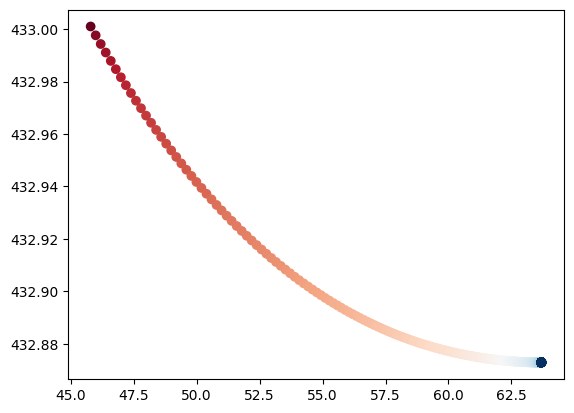

In [13]:
#
# optimisation a = 0.03
#

torch.manual_seed(3)

censor_levels_di = tt(censor_levels_di, dtype=torch.float64)
obs_norm_all = tt(obs_norm_all, dtype=torch.float64)
fixed_noise = norm.sample((103,len(GNM_landonly))).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta_a03_optim = tt(theta_a03,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta_a03_optim], lr=0.2)

history3 = []

# construct current guess of the Distance Matrix
estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
0.03*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

for epoch in range(500):
    optimizer.zero_grad()    

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta_a03_optim)

    # sample
    chol_cov_est = torch.linalg.cholesky(estimated_cov)
    sims_z_est = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est) # on the Gaussian Z-space
    SR = 0
    for i in range(50): # loop over all days in subsets
        day_subset = range(i*103,(i+1)*103)
        sim_z_est_censored = torch.maximum(sims_z_est, censor_levels_di[day_subset,:] )
        #sims_u_est = norm.cdf(sims_z_est) # convert to U-space
        SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored) 
    # add last batch of days
    day_subset = [day for day in range(5149+1,len(GNM_landonly[0][0]))]
    sim_z_est_censored = torch.maximum(sims_z_est[:len(day_subset)], censor_levels_di[day_subset,:] )
    SR += Energy_Score(0.5, obs_norm_all[day_subset], sim_z_est_censored)
    
    # penalize if estimated_cov is too small 
    if estimated_cov.median() < 0.01:
        SR = SR * (1/estimated_cov.mean())
        print(epoch,'penalizing', 1e-2* 1/estimated_cov.mean().item())
    SR.backward()

    # Clip gradients
    torch.nn.utils.clip_grad_norm_([theta_a03_optim], max_norm=1e-2)

    if epoch % 1 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {SR.item()}, Theta Gradient = {theta_a03_optim.grad.item()}, Theta = {theta_a03_optim.item()}')
        history3.append([theta_a03_optim.item(), SR.item()])
    optimizer.step()

print(theta_a03_optim)

# Extract theta, a, and SR values from history3
history3 = np.array(history3)

plt.scatter(history3[:, 0], history3[:, 1], c = np.sqrt(np.arange(len(history3))), cmap = 'RdBu')


np.save('theta_a03_optim.npy', history3)